# Energy Efficiency ANN

This notebook implements an Artificial Neural Network (ANN) to predict heating and cooling loads of buildings based on design parameters.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD

# Set random seed for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

## 1. Data Preprocessing

In [11]:
# Load dataset
file_path = 'ENB2012_data.xlsx'
df = pd.read_excel(file_path)

# Rename columns for clarity
column_names = {
    'X1': 'Relative_Compactness',
    'X2': 'Surface_Area',
    'X3': 'Wall_Area',
    'X4': 'Roof_Area',
    'X5': 'Overall_Height',
    'X6': 'Orientation',
    'X7': 'Glazing_Area',
    'X8': 'Glazing_Area_Distribution',
    'Y1': 'Heating_Load',
    'Y2': 'Cooling_Load'
}
df = df.rename(columns=column_names)

# Display first few rows
print("First 5 rows:")
print(df.head())

# Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

# Define Features (X) and Targets (Y)
X = df.drop(columns=['Heating_Load', 'Cooling_Load'])
Y = df[['Heating_Load', 'Cooling_Load']]

# Normalize data (MinMax Scaling)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

print(f"\nTraining shape: {X_train.shape}")
print(f"Testing shape: {X_test.shape}")

First 5 rows:
   Relative_Compactness  Surface_Area  Wall_Area  Roof_Area  Overall_Height  \
0                  0.98         514.5      294.0     110.25             7.0   
1                  0.98         514.5      294.0     110.25             7.0   
2                  0.98         514.5      294.0     110.25             7.0   
3                  0.98         514.5      294.0     110.25             7.0   
4                  0.90         563.5      318.5     122.50             7.0   

   Orientation  Glazing_Area  Glazing_Area_Distribution  Heating_Load  \
0            2           0.0                          0         15.55   
1            3           0.0                          0         15.55   
2            4           0.0                          0         15.55   
3            5           0.0                          0         15.55   
4            2           0.0                          0         20.84   

   Cooling_Load  
0         21.33  
1         21.33  
2         21.33  


## 2. Build ANN Model (ReLU)

In [12]:
def build_model(activation='relu', learning_rate=0.01):

    model = Sequential([
        Dense(64, input_dim=X_train.shape[1], activation=activation),
        Dense(32, activation=activation),
        # Output layer: 2 neurons for Heating & Cooling Load
        Dense(2)
    ])

    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model_relu = build_model(activation='relu')
model_relu.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,722 (10.63 KB)

 Trainable params: 2,722 (10.63 KB)

 Non-trainable params: 0 (0.00 B)

## 3. Train Model

In [13]:
history_relu = model_relu.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 546.1509 - mae: 20.8275 - val_loss: 104.9556 - val_mae: 8.5967
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 93.8684 - mae: 7.9206 - val_loss: 29.9025 - val_mae: 4.0121
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 23.7362 - mae: 3.7932 - val_loss: 19.1249 - val_mae: 3.1398
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 16.0325 - mae: 2.7744 - val_loss: 15.0428 - val_mae: 2.7804
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 13.1036 - mae: 2.5199 - val_loss: 13.1004 - val_mae: 2.5773
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.9196 - mae: 2.4251 - val_loss: 12.3144 - val_mae: 2.5193
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.3262 - mae: 2.3898 - val_loss: 11.9633 - val_mae: 2.4959
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.0575 - mae: 2.3757 - val_loss: 11.7395 - val_mae: 2.4693
Epoch 9/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5m

## 4. Evaluation

In [14]:
def evaluate_model(model, X_test, y_test, title="Model"):
    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    print(f"--- {title} Evaluation ---")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2 Score: {r2:.4f}")

    return y_pred

y_pred_relu = evaluate_model(model_relu, X_test, y_test, title="ReLU Model")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
--- ReLU Model Evaluation ---
RMSE: 2.8514
R2 Score: 0.9170


## 5. Experiments: Tanh & Sigmoid

In [15]:
# Tanh Model
model_tanh = build_model(activation='tanh')
history_tanh = model_tanh.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

# Sigmoid Model
model_sigmoid = build_model(activation='sigmoid')
history_sigmoid = model_sigmoid.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    verbose=0
)

print("Training complete for Tanh and Sigmoid models.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training complete for Tanh and Sigmoid models.


## 6. Gradient Vanishing Explanation

**Sigmoid:** The derivative of the sigmoid function is at most 0.25. As we backpropagate through many layers, these small gradients are multiplied, causing the gradient to vanish towards the earlier layers. This slows down or stops learning.

**Tanh:** The derivative is at most 1.0, which is better than sigmoid, but it can still suffer from vanishing gradients if the inputs are large (saturation regions).

**ReLU:** The derivative is 1 for positive inputs, which helps mitigate the vanishing gradient problem, allowing deep networks to learn faster and more effectively.

## 7. Plots

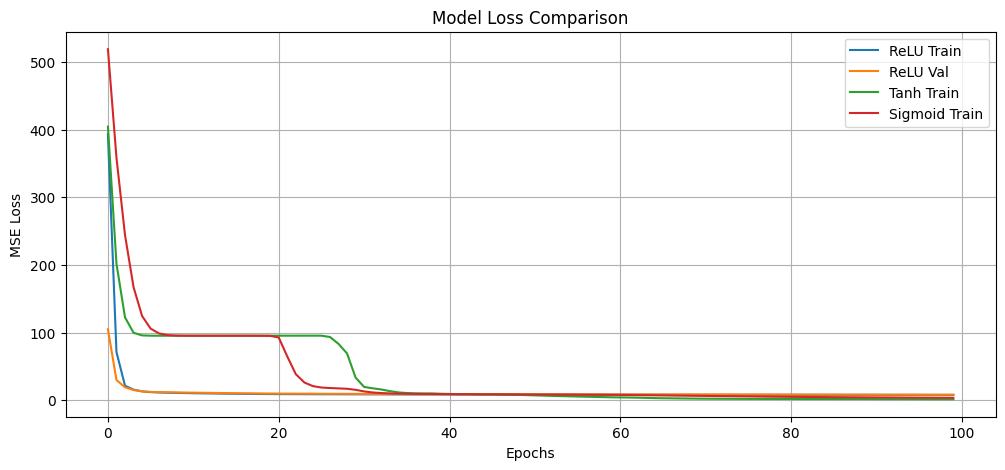

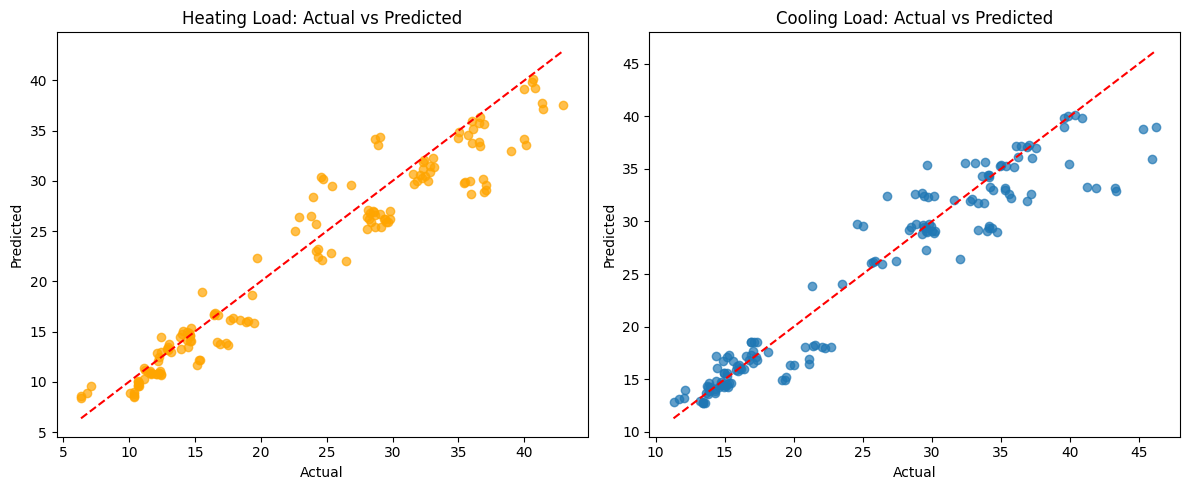

In [17]:
# Loss Curves
plt.figure(figsize=(12, 5))
plt.plot(history_relu.history['loss'], label='ReLU Train')
plt.plot(history_relu.history['val_loss'], label='ReLU Val')
plt.plot(history_tanh.history['loss'], label='Tanh Train')
plt.plot(history_sigmoid.history['loss'], label='Sigmoid Train')
plt.title('Model Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

# Predicted vs Actual (ReLU Model)
plt.figure(figsize=(12, 5))

# Heating Load
plt.subplot(1, 2, 1)
plt.scatter(y_test['Heating_Load'], y_pred_relu[:, 0], alpha=0.7, color='orange')
plt.plot([y_test['Heating_Load'].min(), y_test['Heating_Load'].max()],
         [y_test['Heating_Load'].min(), y_test['Heating_Load'].max()], 'r--')
plt.title('Heating Load: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')

# Cooling Load
plt.subplot(1, 2, 2)
plt.scatter(y_test['Cooling_Load'], y_pred_relu[:, 1], alpha=0.7)
plt.plot([y_test['Cooling_Load'].min(), y_test['Cooling_Load'].max()],
         [y_test['Cooling_Load'].min(), y_test['Cooling_Load'].max()], 'r--')
plt.title('Cooling Load: Actual vs Predicted')
plt.xlabel('Actual')
plt.ylabel('Predicted')

plt.tight_layout()
plt.show()